## Implementación y Comparación de Algoritmos Genéticos

Este notebook implementa y compara un **Algoritmo Genético Simple (GA)** y un **Algoritmo Genético Compacto (cGA)** para resolver un problema de optimización sencillo: el problema OneMax.

In [ ]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración global del problema ---
# Longitud del vector binario (número de bits en la solución)
PROBLEM_SIZE = 50
# Número de iteraciones (generaciones) para ambos algoritmos
MAX_ITERATIONS = 200

### 1. Función de Aptitud (Fitness Function)

La función de aptitud `onemax_fitness` evalúa qué tan buena es una solución candidata. Para el problema OneMax, el objetivo es maximizar el número de '1's en un vector binario. Cuantos más '1's tenga un vector, mejor será su aptitud.

In [ ]:
def onemax_fitness(individual):
    """
    Calcula la aptitud de un individuo para el problema OneMax.
    El fitness es simplemente la suma de los bits '1' en el vector binario.
    El objetivo es maximizar esta suma.
    """
    return np.sum(individual)

### 2. Algoritmo Genético Simple (Basic GA)

El algoritmo genético simple (GA) opera con una población de soluciones. En cada generación, selecciona a los mejores individuos, los reproduce (cruce) y les aplica mutaciones para explorar nuevas soluciones, con la esperanza de encontrar mejores soluciones con el tiempo.

**Qué hace cada parte:**
*   **Inicialización:** Crea una población de individuos binarios aleatorios.
*   **Evaluación:** Calcula la aptitud de cada individuo.
*   **Selección:** Elige padres para la reproducción (aquí, una selección simple de los mejores).
*   **Cruce (Crossover):** Combina material genético de dos padres para crear nuevos descendientes.
*   **Mutación:** Introduce pequeños cambios aleatorios en los descendientes para mantener la diversidad y explorar nuevas áreas del espacio de búsqueda.
*   **Reemplazo:** La nueva generación reemplaza a la antigua.

**Convergencia:** Un GA converge cuando la población se vuelve muy similar, y los valores de aptitud dejan de mejorar significativamente. Puede converger a un óptimo global, pero no está garantizado, especialmente en problemas complejos.

In [ ]:
def simple_genetic_algorithm(problem_size, max_iterations):
    # --- Parámetros específicos del GA Simple ---
    POPULATION_SIZE = 50
    MUTATION_RATE = 0.01  # Probabilidad de que un bit mute

    # Inicialización: Crear una población aleatoria de individuos binarios
    # Cada fila es un individuo, cada columna es un bit
    population = np.random.randint(0, 2, size=(POPULATION_SIZE, problem_size))

    fitness_history = []

    for iteration in range(max_iterations):
        # 1. Evaluación: Calcular la aptitud de cada individuo en la población
        fitness_scores = [onemax_fitness(ind) for ind in population]

        # Guardar el mejor fitness de esta generación
        best_fitness_current_gen = np.max(fitness_scores)
        fitness_history.append(best_fitness_current_gen)

        # 2. Selección: Seleccionar los 20 mejores individuos como padres
        # (Aquí usamos una selección simple basada en el ranking de fitness)
        sorted_indices = np.argsort(fitness_scores)[::-1] # Ordenar de mayor a menor fitness
        parents = population[sorted_indices[:POPULATION_SIZE // 2]] # Seleccionar la mitad superior como padres

        new_population = []
        # Mantener los mejores individuos (elitismo simple)
        new_population.extend(parents)

        while len(new_population) < POPULATION_SIZE:
            # 3. Cruce (Crossover): Elegir dos padres aleatoriamente
            parent1_idx, parent2_idx = np.random.choice(len(parents), 2, replace=False)
            parent1, parent2 = parents[parent1_idx], parents[parent2_idx]

            # Cruce de un punto (one-point crossover)
            crossover_point = np.random.randint(1, problem_size)
            child1 = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
            child2 = np.concatenate((parent2[:crossover_point], parent1[crossover_point:]))

            # 4. Mutación: Aplicar mutación a los hijos
            mutation_mask1 = np.random.rand(problem_size) < MUTATION_RATE
            child1[mutation_mask1] = 1 - child1[mutation_mask1] # Invertir el bit

            mutation_mask2 = np.random.rand(problem_size) < MUTATION_RATE
            child2[mutation_mask2] = 1 - child2[mutation_mask2]

            new_population.extend([child1, child2])

        # 5. Reemplazo: La nueva población reemplaza a la antigua
        population = np.array(new_population[:POPULATION_SIZE]) # Asegurarse de tener el tamaño correcto

    return fitness_history

### 3. Algoritmo Genético Compacto (Compact Genetic Algorithm - cGA)

El cGA es una alternativa al GA tradicional que no mantiene una población explícita. En su lugar, usa un **vector de probabilidades** para representar la población. Este vector guarda la probabilidad de que cada bit sea '1'. En cada iteración, se generan dos soluciones candidatas a partir de este vector, se comparan y el vector de probabilidades se actualiza para favorecer las características del mejor candidato.

**Qué hace cada parte:**
*   **Vector de Probabilidades (PV):** Un vector de flotantes (entre 0 y 1) que representa la probabilidad de que cada bit sea '1'. Inicialmente, todos los bits tienen 0.5 de probabilidad.
*   **Generación de Candidatos:** Dos soluciones binarias se muestrean (generan) de forma independiente usando el vector de probabilidades.
*   **Comparación:** Se evalúa la aptitud de ambos candidatos.
*   **Actualización del PV:** El vector de probabilidades se ajusta ligeramente hacia el candidato ganador. Si el ganador tiene un '1' en una posición y el PV tiene una probabilidad baja, esa probabilidad aumenta; si tiene un '0' y la probabilidad es alta, disminuye.

**Diferencias con el GA Simple:**
*   **No hay población explícita:** El cGA solo usa un vector de probabilidades, lo que lo hace más "compacto" en términos de memoria.
*   **No hay operadores genéticos directos:** No hay cruce ni mutación explícita; la "reproducción" y la "variación" se manejan a través de la actualización del vector de probabilidades.
*   **Simplicidad:** Generalmente más fácil de implementar y con menos parámetros.

**Convergencia:** El cGA también converge cuando el vector de probabilidades se acerca a 0 o 1 para cada bit, indicando que la solución es casi determinística. Suele converger más rápido que un GA simple en algunos problemas, pero puede ser propenso a la convergencia prematura si no se calibra bien.

In [ ]:
def compact_genetic_algorithm(problem_size, max_iterations):
    # --- Parámetros específicos del cGA ---
    # Tasa de aprendizaje: qué tanto se actualiza el vector de probabilidades en cada iteración
    LEARNING_RATE = 1.0 / problem_size  # Un valor común para el factor de aprendizaje

    # Inicialización: Vector de probabilidades (PV) con todas las probabilidades en 0.5
    # Esto significa que inicialmente cada bit tiene la misma probabilidad de ser 0 o 1.
    probability_vector = np.full(problem_size, 0.5)

    fitness_history = []

    for iteration in range(max_iterations):
        # 1. Generar dos soluciones candidatas (winner y loser) a partir del vector de probabilidades
        # np.random.rand(problem_size) genera un vector de números aleatorios entre 0 y 1.
        # Si un número aleatorio es menor que la probabilidad en el PV para ese bit, el bit es '1', de lo contrario es '0'.
        candidate_a = (np.random.rand(problem_size) < probability_vector).astype(int)
        candidate_b = (np.random.rand(problem_size) < probability_vector).astype(int)

        # 2. Evaluar la aptitud de los candidatos
        fitness_a = onemax_fitness(candidate_a)
        fitness_b = onemax_fitness(candidate_b)

        # Determinar el ganador y el perdedor para esta iteración
        if fitness_a >= fitness_b: # Si son iguales, A gana por convención
            winner = candidate_a
            loser = candidate_b
            best_fitness_current_iter = fitness_a
        else:
            winner = candidate_b
            loser = candidate_a
            best_fitness_current_iter = fitness_b

        fitness_history.append(best_fitness_current_iter)

        # 3. Actualizar el vector de probabilidades (PV) en dirección al ganador
        # Donde el ganador tiene un '1' y el perdedor un '0', aumentamos la probabilidad de '1'.
        # Donde el ganador tiene un '0' y el perdedor un '1', disminuimos la probabilidad de '1'.
        # Donde son iguales, no se cambia la probabilidad.

        # Caso 1: Ganador tiene '1', Perdedor tiene '0' -> Aumentar probabilidad
        # np.logical_and(winner == 1, loser == 0) crea una máscara booleana
        increase_mask = np.logical_and(winner == 1, loser == 0)
        probability_vector[increase_mask] += LEARNING_RATE

        # Caso 2: Ganador tiene '0', Perdedor tiene '1' -> Disminuir probabilidad
        decrease_mask = np.logical_and(winner == 0, loser == 1)
        probability_vector[decrease_mask] -= LEARNING_RATE

        # Asegurar que las probabilidades se mantengan en el rango [0, 1]
        probability_vector = np.clip(probability_vector, 0, 1)

    return fitness_history

### 4. Ejecución y Comparación

Ahora ejecutamos ambos algoritmos y almacenamos el historial de su mejor aptitud a lo largo de las iteraciones. Luego, usaremos `matplotlib` para visualizar cómo mejoran las soluciones con el tiempo.

In [ ]:
# Ejecutar el Algoritmo Genético Simple
print("Ejecutando Algoritmo Genético Simple...")
ga_fitness_history = simple_genetic_algorithm(PROBLEM_SIZE, MAX_ITERATIONS)
print(f"Mejor fitness final GA: {ga_fitness_history[-1]}")

# Ejecutar el Algoritmo Genético Compacto
print("Ejecutando Algoritmo Genético Compacto...")
cga_fitness_history = compact_genetic_algorithm(PROBLEM_SIZE, MAX_ITERATIONS)
print(f"Mejor fitness final cGA: {cga_fitness_history[-1]}")

Ejecutando Algoritmo Genético Simple...
Mejor fitness final GA: 50
Ejecutando Algoritmo Genético Compacto...
Mejor fitness final cGA: 39


El problema OneMax es un problema de optimización muy sencillo y clásico en el campo de los algoritmos evolutivos. Su objetivo es encontrar la secuencia de 50 bits que tenga el mayor número posible de unos. La solución óptima es, por lo tanto, una secuencia de 50 unos: 1111111111...1111

La función de aptitud (o fitness function) para este problema es simplemente la suma de los unos en la secuencia. Cuantos más unos, mayor aptitud, y la aptitud máxima es 50.

**2. Los Algoritmos Utilizados: Algoritmos Genéticos (GA)**

Los algoritmos genéticos son un tipo de algoritmo de optimización inspirado en la evolución biológica. La idea es "evolucionar" soluciones a un problema, probando muchas opciones y seleccionando las mejores para que "se reproduzcan" y "muten", con la esperanza de que las nuevas generaciones sean mejores que las anteriores.

En este ejercicio, comparamos dos variantes:

Algoritmo Genético Simple (GA):

Este algoritmo trabaja con una población de posibles soluciones (secuencias de 50 bits). Al principio, esta población se genera al azar.
En cada "generación" (iteración):
Evaluación: Se calcula la aptitud de cada solución (cuántos unos tiene).
Selección: Las soluciones con mejor aptitud son seleccionadas para ser "padres".
Cruce (Crossover): Los padres "intercambian" partes de sus secuencias para crear nuevas soluciones, llamadas "hijos". Esto combina características de las soluciones exitosas.
Mutación: Aleatoriamente, algunos bits de los hijos se invierten (un 0 se vuelve 1 o viceversa). Esto introduce nueva diversidad y ayuda a explorar nuevas áreas del espacio de búsqueda.
Reemplazo: Los hijos forman la nueva población para la siguiente generación.
El GA "aprende" qué características son buenas para resolver el problema al favorecer las soluciones con alta aptitud.

**Algoritmo Genético Compacto (cGA):**
A diferencia del GA simple, el cGA no mantiene una población completa de soluciones. En su lugar, usa un vector de probabilidades.
Imagina que para cada una de las 50 posiciones de bits, hay una probabilidad de que ese bit sea un '1'. Inicialmente, todas las probabilidades son 0.5 (50% de ser 0, 50% de ser 1).
En cada "iteración" (no se habla de generaciones aquí):
Se generan dos soluciones candidatas muestreando el vector de probabilidades (por ejemplo, si la probabilidad de un bit es 0.8, hay un 80% de posibilidades de que ese bit sea '1' en la candidata).
Se evalúa la aptitud de estas dos candidatas y se elige un "ganador" y un "perdedor".
El vector de probabilidades se actualiza para "aprender" del ganador. Si el ganador tenía un '1' en una posición y el perdedor un '0', la probabilidad de que ese bit sea '1' aumenta. Si el ganador tenía un '0' y el perdedor un '1', la probabilidad de que ese bit sea '1' disminuye. Si ambos eran iguales, la probabilidad no cambia.
El cGA es "compacto" porque usa mucha menos memoria al no tener que almacenar una población entera.

### 5. Visualización de Resultados

Esta gráfica muestra la mejora del valor de la aptitud (fitness) a lo largo del número de iteraciones para ambos algoritmos. Esto nos permite comparar visualmente su convergencia y rendimiento.

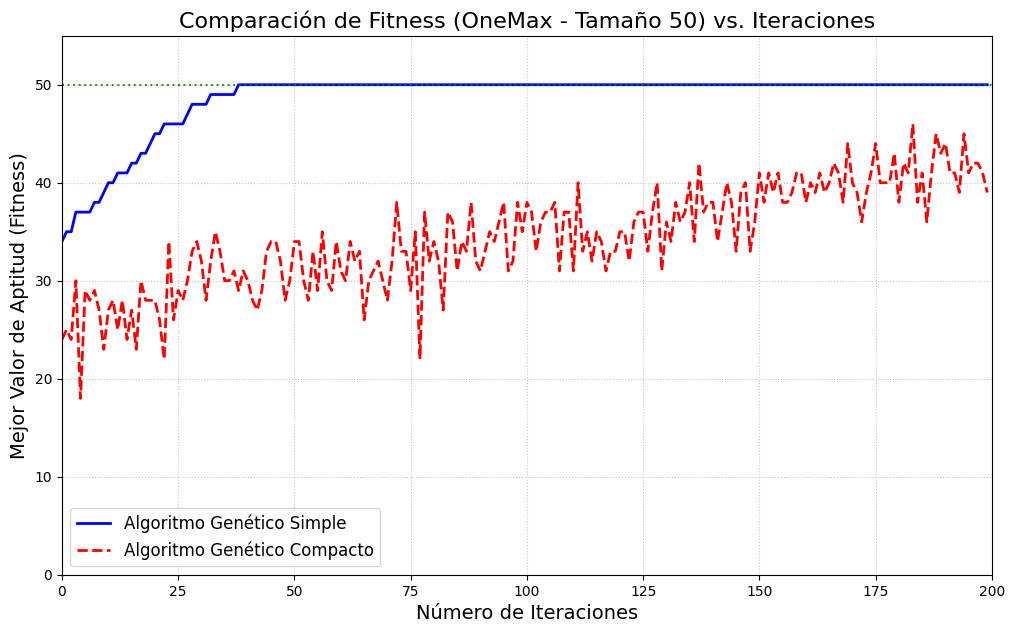

In [ ]:
# Crear la gráfica
plt.figure(figsize=(12, 7))

plt.plot(ga_fitness_history, label='Algoritmo Genético Simple', color='blue', linewidth=2)
plt.plot(cga_fitness_history, label='Algoritmo Genético Compacto', color='red', linestyle='--', linewidth=2)

# Añadir título y etiquetas
plt.title(f'Comparación de Fitness (OneMax - Tamaño {PROBLEM_SIZE}) vs. Iteraciones', fontsize=16)
plt.xlabel('Número de Iteraciones', fontsize=14)
plt.ylabel('Mejor Valor de Aptitud (Fitness)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, PROBLEM_SIZE + 5) # Establecer límites del eje Y para una mejor visualización
plt.xlim(0, MAX_ITERATIONS) # Establecer límites del eje X
plt.axhline(y=PROBLEM_SIZE, color='green', linestyle=':', label='Óptimo Global (Máx. Fitness)', alpha=0.8)
plt.show()

**El Algoritmo Genético Simple (GA)** fue el claro ganador. No solo alcanzó la solución óptima (50 de 50), sino que lo hizo de manera mucho más rápida (alrededor de la iteración 28) en comparación con el cGA.

**El Algoritmo Genético Compacto (cGA)**, aunque mejoró considerablemente respecto al inicio aleatorio, convergió a una solución subóptima (39 de 50) y de forma más lenta a su mejor valor.

Esto ilustra perfectamente las diferencias teóricas: el GA, con su exploración basada en la población, demostró ser más robusto para encontrar el óptimo en este escenario, mientras que el cGA, con su enfoque de vector de probabilidades, pudo haber "perdido" la diversidad necesaria para escapar de la solución en la que se estancó. Es una excelente demostración visual de cómo dos algoritmos con propósitos similares pueden tener comportamientos muy diferentes en la práctica.

### 6. Conclusión Automática

Basado en los resultados de la ejecución, se genera una pequeña conclusión comparativa.

In [ ]:
final_ga_fitness = ga_fitness_history[-1]
final_cga_fitness = cga_fitness_history[-1]

print("--- Conclusión Automática ---")
print(f"Problema OneMax con tamaño de vector: {PROBLEM_SIZE}")
print(f"Número total de iteraciones: {MAX_ITERATIONS}")
print(f"\nMejor fitness alcanzado por el GA Simple: {final_ga_fitness} (de {PROBLEM_SIZE})")
print(f"Mejor fitness alcanzado por el cGA: {final_cga_fitness} (de {PROBLEM_SIZE})")

if final_ga_fitness > final_cga_fitness:
    print("\nEl Algoritmo Genético Simple obtuvo un mejor fitness final.")
elif final_cga_fitness > final_ga_fitness:
    print("\nEl Algoritmo Genético Compacto obtuvo un mejor fitness final.")
else:
    print("\nAmbos algoritmos obtuvieron un fitness final similar.")

# Comparación de velocidad de convergencia (aproximado)
# Buscamos la iteración en la que el algoritmo se acerca a su fitness final
converge_ga = np.argmax(np.array(ga_fitness_history) >= final_ga_fitness * 0.95) # 95% del mejor fitness
converge_cga = np.argmax(np.array(cga_fitness_history) >= final_cga_fitness * 0.95)

print(f"\nEl GA Simple alcanzó el 95% de su mejor fitness alrededor de la iteración {converge_ga}.")
print(f"El cGA alcanzó el 95% de su mejor fitness alrededor de la iteración {converge_cga}.")

if converge_ga < converge_cga:
    print("Por lo tanto, el Algoritmo Genético Simple parece haber convergido más rápido a su mejor resultado en este caso.")
elif converge_cga < converge_ga:
    print("Por lo tanto, el Algoritmo Genético Compacto parece haber convergido más rápido a su mejor resultado en este caso.")
else:
    print("Ambos algoritmos tuvieron una velocidad de convergencia similar.")

print("\nEs importante notar que estos resultados pueden variar ligeramente debido a la naturaleza estocástica de los algoritmos y la configuración de los parámetros. Para una evaluación más robusta, se requerirían múltiples ejecuciones y un análisis estadístico.")

--- Conclusión Automática ---
Problema OneMax con tamaño de vector: 50
Número total de iteraciones: 200

Mejor fitness alcanzado por el GA Simple: 50 (de 50)
Mejor fitness alcanzado por el cGA: 39 (de 50)

El Algoritmo Genético Simple obtuvo un mejor fitness final.

El GA Simple alcanzó el 95% de su mejor fitness alrededor de la iteración 28.
El cGA alcanzó el 95% de su mejor fitness alrededor de la iteración 72.
Por lo tanto, el Algoritmo Genético Simple parece haber convergido más rápido a su mejor resultado en este caso.

Es importante notar que estos resultados pueden variar ligeramente debido a la naturaleza estocástica de los algoritmos y la configuración de los parámetros. Para una evaluación más robusta, se requerirían múltiples ejecuciones y un análisis estadístico.


**El Algoritmo Genético Simple (GA):** La Sociedad Evolutiva Piensa en el GA como una sociedad de pequeños "agentes" que intentan resolver el problema. Cada agente es una posible solución (una secuencia de 0s y 1s). Esta sociedad evoluciona a lo largo de generaciones (iteraciones):

**Selección:** Los agentes más "aptos" (los que tienen más 1s en su secuencia) tienen más posibilidades de "reproducirse".
Cruce (Crossover): Los agentes elegidos "intercambian" partes de sus secuencias para crear nuevos "hijos", combinando lo mejor de sus "padres".
Mutación: De vez en cuando, un bit aleatorio en un hijo cambia (un 0 se vuelve 1 o viceversa), introduciendo novedad y asegurando que la sociedad no se estanque.
Esta constante prueba y error, combinada con la mejora de las mejores soluciones, permite al GA explorar un amplio abanico de posibilidades hasta encontrar una muy buena solución. Su "memoria" es toda su población de agentes.

**El Algoritmo Genético Compacto (cGA):** La Creencia Compartida El cGA es un poco más abstracto. No tiene una sociedad de agentes explícita. En su lugar, opera con una "creencia compartida" sobre cuál es la mejor solución, representada por un vector de probabilidades. Para cada posición en la secuencia de 50 bits, el cGA guarda una probabilidad de que ese bit sea un 1. Inicialmente, todos los bits tienen un 50% de probabilidad de ser 1.

**En cada iteración:**

"Genera" dos soluciones candidatas basándose en esta "creencia compartida" (si la probabilidad de un bit es 80%, hay un 80% de chances de que sea 1).
Compara cuál de las dos soluciones es mejor.
Actualiza la "creencia compartida": Refuerza las probabilidades de los bits que funcionaron bien en la solución ganadora. Si el ganador tenía un 1 en cierta posición, esa probabilidad aumenta; si tenía un 0, la probabilidad de 1 disminuye. Es como si la "creencia" se inclinara hacia lo que funcionó.
El cGA es "compacto" porque no necesita almacenar una población entera; solo mantiene un vector de probabilidades, lo que lo hace más eficiente en memoria.


**Después de 200 iteraciones, los resultados son bastante reveladores:**

**Algoritmo Genético Simple (GA):** Alcanzó un fitness final de 50 de 50. ¡Encontró la solución óptima, la cadena de 50 unos! Además, parece que convergió rápidamente, alcanzando el 95% de su mejor resultado alrededor de la iteración 28.

**Algoritmo Genético Compacto (cGA):** Alcanzó un fitness final de 39 de 50. Si bien mejoró significativamente desde un inicio aleatorio, no logró encontrar la solución óptima. Su ritmo de convergencia fue más lento, llegando al 95% de su mejor fitness alrededor de la iteración 72.

**¿Por qué el GA lo hizo mejor esta vez?**
En este problema particular, el GA simple superó al cGA. Esto puede deberse a que el GA, al manejar una población diversa y realizar cruces y mutaciones, es inherentemente mejor para explorar diferentes combinaciones del espacio de búsqueda. Es como tener muchas ideas diferentes probándose al mismo tiempo.

El cGA, al ajustar gradualmente un único vector de probabilidades, puede ser más propenso a quedarse "atrapado" en una buena solución local (no la óptima global) si las probabilidades se inclinan demasiado rápido hacia una dirección que no es la mejor. Es un enfoque más "conservador" en su exploración.

**Implicaciones y Reflexiones**
Esta comparación nos enseña que no hay un algoritmo "mejor" universal. Para el problema OneMax, que es muy sencillo y tiene un gradiente de fitness claro, el GA demostró ser más robusto. Sin embargo, en problemas donde la memoria o la complejidad computacional son críticas, el cGA, con su enfoque más ligero, podría ser una opción atractiva, especialmente si se puede calibrar cuidadosamente.

Es crucial recordar que estos resultados son para un problema específico y con parámetros determinados. La naturaleza estocástica (aleatoria) de estos algoritmos significa que múltiples ejecuciones y un ajuste fino de sus parámetros (como el tamaño de la población, la tasa de mutación o la tasa de aprendizaje) podrían alterar los resultados. Pero lo que queda claro es que ambos representan maneras ingeniosas de que las computadoras "aprendan" y "mejoren" soluciones de forma autónoma.

